## Phase 1A - Dataset Understanding + RUL Engineering

In [88]:
import pandas as pd
import numpy as np

# Define column names
columns = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1, 4)]
    + [f'sensor_{i}' for i in range(1, 22)]
)

# Load training data
train_df = pd.read_csv(
    '../data/raw/train/train_FD001.txt',
    sep=r'\s+',
    header=None
)

# Remove extra empty columns if present
train_df.dropna(axis=1, inplace=True)

# Assign column names
train_df.columns = columns

# Preview data
train_df.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [89]:
print("Shape:", train_df.shape)

Shape: (20631, 26)


In [90]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [91]:
# Find maximum cycle for each engine
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()

max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back
train_df = train_df.merge(max_cycles, on='engine_id')

# Compute Remaining Useful Life
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Preview
train_df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head()

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [92]:
train_df[['engine_id', 'cycle', 'max_cycle', 'RUL']].tail()

,engine_id,cycle,max_cycle,RUL
20626,100,196,200,4
20627,100,197,200,3
20628,100,198,200,2
20629,100,199,200,1
20630,100,200,200,0


In [93]:
train_df.to_csv(
    '../data/processed/train_with_rul.csv',
    index=False
)

## Phase 1B — Sensor Analysis + Feature Engineering

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [95]:
sensor_cols = [col for col in train_df.columns if 'sensor' in col]

print(sensor_cols)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [96]:
#Variance Analysis - Purpose: Find sensors that barely change.

#Low-variance sensors contribute almost nothing.
variance = train_df[sensor_cols].var().sort_values()

print(variance)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.926023e-34
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


In [97]:
#These contribute almost no predictive information.
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

In [98]:
# Drop low-variance sensors
train_df = train_df.drop(columns=drop_sensors)

# Verify remaining columns
print(train_df.columns)

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'max_cycle', 'RUL'],
      dtype='object')


In [99]:
train_df = train_df.drop(columns=['op_setting_3'])

In [100]:
#Define Final Feature Set
selected_features = [
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_6',
    'sensor_7',
    'sensor_8',
    'sensor_9',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_14',
    'sensor_15',
    'sensor_17',
    'sensor_20',
    'sensor_21'
]

In [101]:
# Normalize Features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_df[selected_features] = scaler.fit_transform(
    train_df[selected_features]
)

In [102]:
# Verify Scaling
train_df[selected_features].describe()

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.443052,0.424746,0.450435,0.980321,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.150618,0.133664,0.151935,0.138898,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.335843,0.331807,0.339467,1.000000,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.430723,0.415522,0.435348,1.000000,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.539157,0.508829,0.545324,1.000000,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
#Save Processed Dataset
train_df.to_csv(
    '../data/processed/train_final_processed.csv',
    index=False
)

## Phase 2 — Sequence Window Generation + GRU Model

In [104]:
import numpy as np

In [105]:
sequence_length = 30 # Hyper Parameter

In [106]:
#Add RUL Clipping
train_df['RUL'] = train_df['RUL'].clip(upper=125)

In [107]:
# Create Sequence Generation Function
def create_sequences(df, sequence_length, feature_cols):

    X = []
    y = []

    engine_ids = df['engine_id'].unique()

    for engine_id in engine_ids:

        engine_data = df[df['engine_id'] == engine_id]

        feature_array = engine_data[feature_cols].values
        rul_array = engine_data['RUL'].values

        for i in range(len(engine_data) - sequence_length):

            X.append(
                feature_array[i:i + sequence_length]
            )

            y.append(
                rul_array[i + sequence_length]
            )

    return np.array(X), np.array(y)

In [108]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_df[selected_features] = scaler.fit_transform(
    train_df[selected_features]
)

In [109]:
# Generate Sequences
X, y = create_sequences(
    train_df,
    sequence_length,
    selected_features
)

In [110]:
print("X shape:", X.shape)
print("y shape:", y.shape)
''' 
30 = timesteps
15 = features 
'''

X shape: (17631, 30, 15)
y shape: (17631,)


' \n30 = timesteps\n15 = features \n'

In [111]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [112]:
print(X_train.shape)
print(X_val.shape)

(14104, 30, 15)
(3527, 30, 15)


In [113]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([

    GRU(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.3),

    GRU(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1)
])

C:\Projects\VALIARIA_Pred_maint\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 30, 128)             │          55,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,553 (373.25 KB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
#Train Model
history = model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=64,

    validation_data=(X_val, y_val),

    callbacks=[early_stop]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - loss: 8771.0332 - mae: 74.5880 - val_loss: 3736.4600 - val_mae: 50.0272
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 3878.4570 - mae: 50.6785 - val_loss: 1474.2378 - val_mae: 27.7189
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1334.3536 - mae: 25.8871 - val_loss: 1012.5933 - val_mae: 20.4829
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1077.4557 - mae: 22.7569 - val_loss: 1004.0031 - val_mae: 21.8593
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1053.9987 - mae: 22.1706 - val_loss: 976.8159 - val_mae: 21.1148
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1033.7190 - mae: 21.9813 - val_loss: 942.7082 - val_mae: 20.7972
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 1045.6262 - mae: 22.0260 - val_loss: 927.1075 - val_mae: 19.8802
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1011.6630 - mae: 21.5963 - val_loss: 942.6479 - val_

In [35]:
#Evaluate Model
from sklearn.metrics import mean_squared_error
predictions = model.predict(X_val)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("Improved RMSE:", rmse)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Improved RMSE: 25.99694806306598


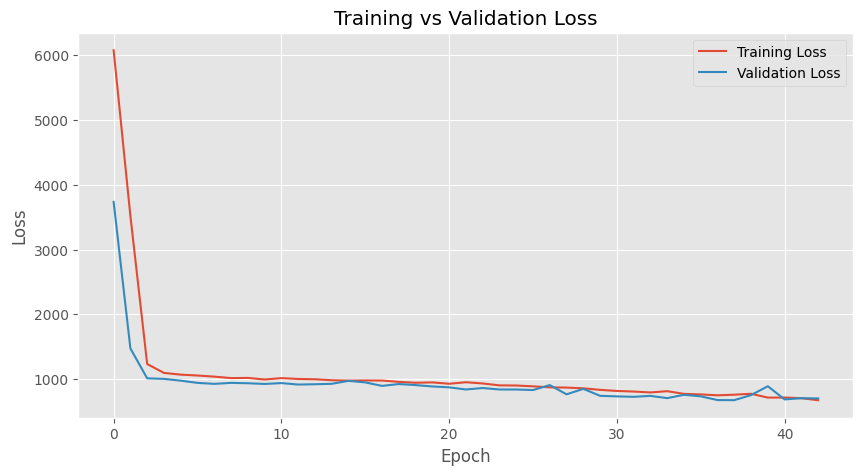

In [36]:
# Visualize Training Curves
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

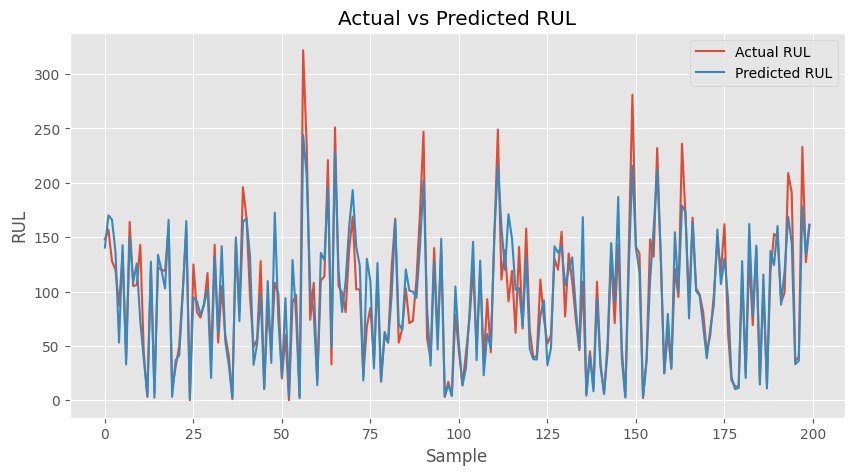

In [37]:
# Then Check Prediction Quality
plt.figure(figsize=(10,5))

plt.plot(y_val[:200], label='Actual RUL')
plt.plot(predictions[:200], label='Predicted RUL')

plt.xlabel('Sample')
plt.ylabel('RUL')

plt.title('Actual vs Predicted RUL')

plt.legend()
plt.show()

### ONE more optimization round

## Bidirectional GRU + Learning Rate Reduction

In [114]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [115]:
model = Sequential([

    Bidirectional(
        GRU(
            128,
            return_sequences=True
        ),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.3),

    Bidirectional(
        GRU(64)
    ),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1)
])

C:\Projects\VALIARIA_Pred_maint\venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [116]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [117]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

In [118]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [120]:
history = model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=64,

    validation_data=(X_val, y_val),

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 188.2984 - mae: 10.0180 - val_loss: 166.1903 - val_mae: 9.1254 - learning_rate: 1.2500e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 182.5171 - mae: 9.9108 - val_loss: 164.4580 - val_mae: 9.1494 - learning_rate: 1.2500e-04
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 183.2973 - mae: 9.9365 - val_loss: 167.5952 - val_mae: 9.3698 - learning_rate: 1.2500e-04
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 179.6951 - mae: 9.7799 - val_loss: 163.9633 - val_mae: 9.1997 - learning_rate: 1.2500e-04
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 182.7771 - mae: 9.8377 - val_loss: 168.8329 - val_mae: 9.3269 - learning_rate: 1.2500e-04
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 203.8793 - mae: 10.4224 - val_loss: 167.1468 - val_mae: 9.3690 - learning_rate: 1.2500e-04
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 188.1427 - mae: 10.1140 

In [121]:
predictions = model.predict(X_val)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("Final Optimized RMSE:", rmse)

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
Final Optimized RMSE: 12.758720856172934


## Phase 3 — Maintenance Decision Engine

In [122]:
# Generate Predictions for Entire Validation Set
predictions = model.predict(X_val)

predictions = predictions.flatten()

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [123]:
# Create Results DataFrame
results_df = pd.DataFrame({

    'Actual_RUL': y_val,
    'Predicted_RUL': predictions
})

results_df.sample(10)

,Actual_RUL,Predicted_RUL
3502,22,16.576263
1715,51,56.462399
2242,119,106.750038
198,125,117.867790
2819,73,75.823875
462,125,109.403824
2858,1,1.518520
1203,37,40.788891
390,26,29.790157
1303,13,14.225516


In [124]:
# Create Maintenance Categories
def maintenance_action(rul):

    if rul < 20:
        return "Immediate Maintenance"

    elif rul < 50:
        return "Schedule Maintenance"

    elif rul < 80:
        return "Monitor Closely"

    else:
        return "Healthy"

In [125]:
# Apply Decision Logic
results_df['Maintenance_Action'] = results_df[
    'Predicted_RUL'
].apply(maintenance_action)

In [126]:
#Check Distribution
results_df['Maintenance_Action'].value_counts()

Maintenance_Action
Healthy                  2023
Schedule Maintenance      553
Monitor Closely           531
Immediate Maintenance     420
Name: count, dtype: int64

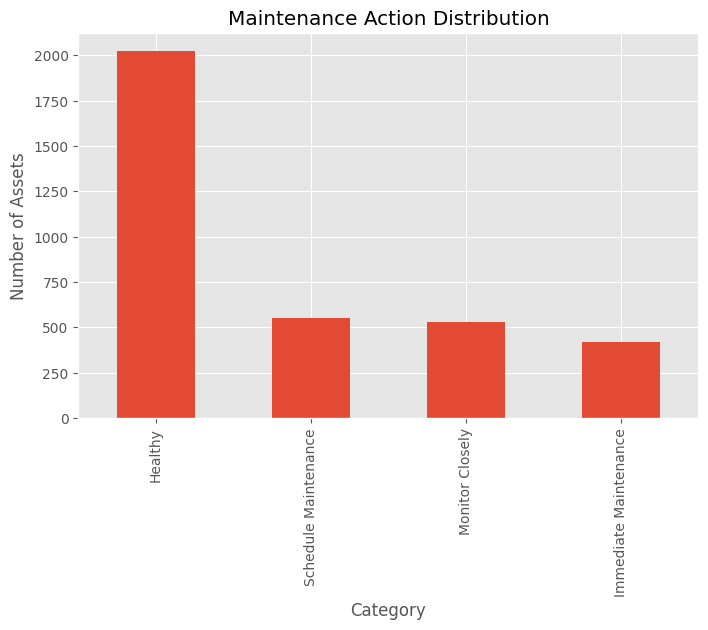

In [127]:
#Visualize Maintenance Risk

plt.figure(figsize=(8,5))

results_df['Maintenance_Action'].value_counts().plot(
    kind='bar'
)

plt.title("Maintenance Action Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Assets")

plt.show()

In [128]:
# Add Failure Probability Score
results_df['Failure_Probability'] = 1 - (
    results_df['Predicted_RUL'] / 125
)

results_df['Failure_Probability'] = results_df[
    'Failure_Probability'
].clip(0,1)

In [129]:
results_df.to_csv(
    '../data/processed/maintenance_predictions.csv',
    index=False
)

## Phase 4 — Financial Impact Modeling

### Add Maintenance Cost Assumptions

Since real industrial cost databases are proprietary, academic projects typically use:
- simulated cost models
- industry-inspired estimates

In [130]:
# Define Cost Logic
def estimated_maintenance_cost(action):

    if action == "Immediate Maintenance":
        return 500000

    elif action == "Schedule Maintenance":
        return 250000

    elif action == "Monitor Closely":
        return 50000

    else:
        return 10000

In [131]:
# Apply Cost Estimation
results_df['Maintenance_Cost'] = results_df[
    'Maintenance_Action'
].apply(estimated_maintenance_cost)

In [132]:
# Model Downtime Hours
def estimated_downtime(action):

    if action == "Immediate Maintenance":
        return 72

    elif action == "Schedule Maintenance":
        return 24

    elif action == "Monitor Closely":
        return 6

    else:
        return 1

In [133]:
#Apply downtime estimation
results_df['Downtime_Hours'] = results_df[
    'Maintenance_Action'
].apply(estimated_downtime)

In [134]:
# Production Loss Calculation
REVENUE_LOSS_PER_HOUR = 20000

results_df['Production_Loss'] = (

    results_df['Downtime_Hours']
    * REVENUE_LOSS_PER_HOUR
)

### Formula used 
- Production Loss = Downtime Hours * Revenue Loss per Hour

In [135]:
# Total Financial Impact
results_df['Total_Financial_Impact'] = (

    results_df['Maintenance_Cost']
    + results_df['Production_Loss']
)

In [136]:
# Results 
results_df.sample(10)

,Actual_RUL,Predicted_RUL,Maintenance_Action,Failure_Probability,Maintenance_Cost,Downtime_Hours,Production_Loss,Total_Financial_Impact
3064,46,53.667236,Monitor Closely,0.570662,50000,6,120000,170000
3073,98,114.966194,Healthy,0.080270,10000,1,20000,30000
987,125,120.365585,Healthy,0.037075,10000,1,20000,30000
779,27,25.438656,Schedule Maintenance,0.796491,250000,24,480000,730000
781,100,115.704041,Healthy,0.074368,10000,1,20000,30000
311,23,27.151602,Schedule Maintenance,0.782787,250000,24,480000,730000
3253,14,13.869956,Immediate Maintenance,0.889040,500000,72,1440000,1940000
2367,4,2.564231,Immediate Maintenance,0.979486,500000,72,1440000,1940000
2330,102,112.629036,Healthy,0.098968,10000,1,20000,30000
2007,118,113.434036,Healthy,0.092528,10000,1,20000,30000


In [137]:
#Portfolio-Level Financial Forecast
total_cost = results_df[
    'Total_Financial_Impact'
].sum()

print("Projected Maintenance Exposure: ₹", total_cost)

Projected Maintenance Exposure: ₹ 1369450000


In [138]:
# Risk-Based Financial Summary
results_df.groupby(
    'Maintenance_Action'
)[
    'Total_Financial_Impact'
].mean()

Maintenance_Action
Healthy                    30000.0
Immediate Maintenance    1940000.0
Monitor Closely           170000.0
Schedule Maintenance      730000.0
Name: Total_Financial_Impact, dtype: float64

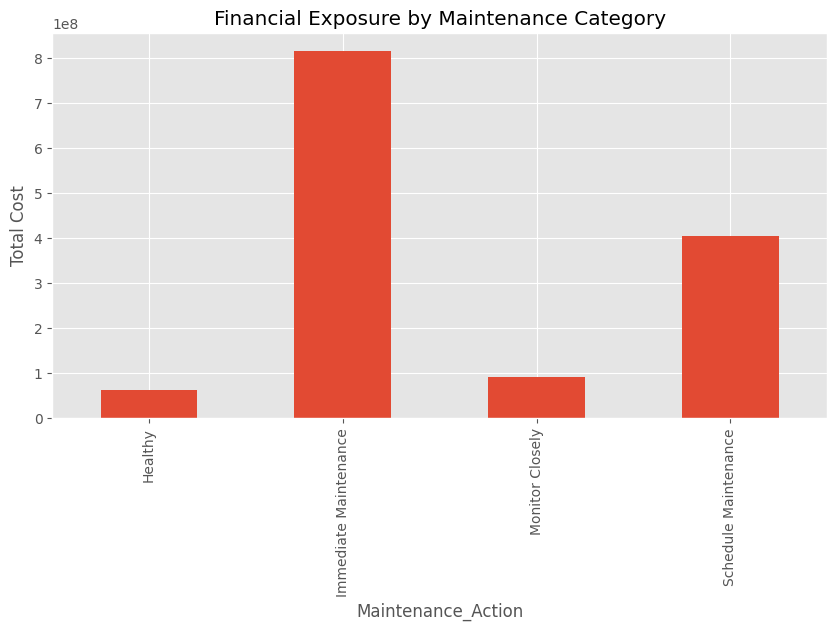

In [139]:
plt.figure(figsize=(10,5))

results_df.groupby(
    'Maintenance_Action'
)[
    'Total_Financial_Impact'
].sum().plot(kind='bar')

plt.title("Financial Exposure by Maintenance Category")
plt.ylabel("Total Cost")

plt.show()

## Phase 5 — Monte Carlo Financial Risk Simulation

- Instead of saying:- “Expected maintenance cost = ₹5 crore”
- We forecast:- “Maintenance cost is likely between ₹4.2–₹6.8 crore with 95% confidence.”

In [140]:
import numpy as np


In [141]:
# Define Simulation Parameters

NUM_SIMULATIONS = 10000

# This means: 10,000 possible future maintenance scenarios
#Very standard in financial risk modeling.

In [142]:
#Prepare Base Cost

base_costs = results_df[
    'Total_Financial_Impact'
].values

### IMPORTANT IDEA
- current costs are deterministic.
- Monte Carlo introduces variability around them.

- Because in reality:
  - repairs may become costlier
  - downtime may extend
  - failures may cascade

In [143]:
# Monte Carlo Simulation
simulation_totals = []

for _ in range(NUM_SIMULATIONS):

    simulated_costs = []

    for cost in base_costs:

        # Add random variability
        random_multiplier = np.random.normal(
            loc=1.0,
            scale=0.15
        )

        simulated_cost = cost * random_multiplier

        simulated_costs.append(simulated_cost)

    simulation_totals.append(
        np.sum(simulated_costs)
    )

In [144]:
# Convert to NumPy Array
simulation_totals = np.array(simulation_totals)

In [145]:
# Compute Financial Risk Metrics
mean_cost = np.mean(simulation_totals)

p5 = np.percentile(simulation_totals, 5)
p95 = np.percentile(simulation_totals, 95)

worst_case = np.max(simulation_totals)
best_case = np.min(simulation_totals)

In [146]:
# Display Results

print("Expected Maintenance Cost: ₹", round(mean_cost,2))

print("5th Percentile: ₹", round(p5,2))
print("95th Percentile: ₹", round(p95,2))

print("Best Case: ₹", round(best_case,2))
print("Worst Case: ₹", round(worst_case,2))

Expected Maintenance Cost: ₹ 1369344308.56
5th Percentile: ₹ 1358532471.67
95th Percentile: ₹ 1379964658.46
Best Case: ₹ 1347060338.63
Worst Case: ₹ 1392844110.15


### IMPORTANT INTERPRETATION

| Metric          | Meaning                       |
| --------------- | ----------------------------- |
| Mean            | expected maintenance exposure |
| 5th percentile  | optimistic scenario           |
| 95th percentile | severe-risk scenario          |
| Worst case      | extreme tail event            |


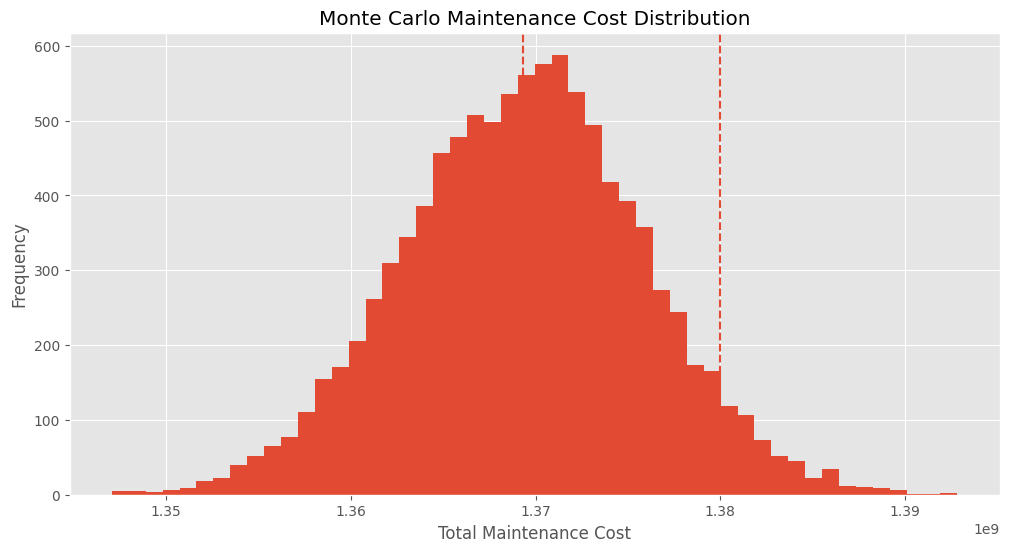

In [147]:
# Visualize Distribution
plt.figure(figsize=(12,6))

plt.hist(
    simulation_totals,
    bins=50
)

plt.axvline(mean_cost, linestyle='dashed')
plt.axvline(p95, linestyle='dashed')

plt.title("Monte Carlo Maintenance Cost Distribution")

plt.xlabel("Total Maintenance Cost")
plt.ylabel("Frequency")

plt.show()

In [148]:
# Confidence Interval
# calculate a formal confidence interval.

confidence_interval = (p5, p95)

print("90% Confidence Interval:")
print(confidence_interval)

90% Confidence Interval:
(np.float64(1358532471.6743755), np.float64(1379964658.4631152))


In [149]:
# Save Simulation Results
simulation_df = pd.DataFrame({
    'Simulated_Total_Cost': simulation_totals
})

simulation_df.to_csv(
    '../data/processed/monte_carlo_results.csv',
    index=False
)

In [150]:
print(results_df.columns)

Index(['Actual_RUL', 'Predicted_RUL', 'Maintenance_Action',
       'Failure_Probability', 'Maintenance_Cost', 'Downtime_Hours',
       'Production_Loss', 'Total_Financial_Impact'],
      dtype='object')


In [151]:
results_df.to_csv(
    '../data/processed/maintenance_predictions.csv',
    index=False
)

print("Saved successfully")

Saved successfully


In [152]:
check_df = pd.read_csv(
    '../data/processed/maintenance_predictions.csv'
)

print(check_df.columns)


Index(['Actual_RUL', 'Predicted_RUL', 'Maintenance_Action',
       'Failure_Probability', 'Maintenance_Cost', 'Downtime_Hours',
       'Production_Loss', 'Total_Financial_Impact'],
      dtype='object')


## SHAP Upgrade 

In [153]:
import shap
import matplotlib.pyplot as plt

In [154]:
#Prepare Sample Data
X_sample = X_train[:200]

In [155]:
#Create SHAP Explainer
explainer = shap.GradientExplainer(
    model,
    X_sample
)

In [156]:
#Generate SHAP Values
shap_values = explainer.shap_values(
    X_val[:50]
)

C:\Projects\VALIARIA_Pred_maint\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(50, 30, 15))']
  warnings.warn(msg)


In [157]:
Convert SHAP Output
shap_values = np.array(shap_values)

print(shap_values.shape)

# (samples, timesteps, features, outputs)

(50, 30, 15, 1)


In [162]:
#Aggregate Across Timesteps
shap_importance = np.mean(
    np.abs(shap_values),
    axis=(0,1,3)
)

print(shap_importance.shape)

(15,)


In [163]:
#Create Feature Importance DataFrame
importance_df = pd.DataFrame({

    'Feature': selected_features,

    'Importance': shap_importance
})

importance_df = importance_df.sort_values(

    by='Importance',

    ascending=False
)

print(importance_df)

      Feature  Importance
7   sensor_11    0.981956
8   sensor_12    0.813881
9   sensor_13    0.770975
4    sensor_7    0.699892
5    sensor_8    0.646455
6    sensor_9    0.609853
2    sensor_4    0.568671
0    sensor_2    0.538308
13  sensor_20    0.509407
11  sensor_15    0.473001
10  sensor_14    0.418549
12  sensor_17    0.317493
14  sensor_21    0.304130
1    sensor_3    0.237275
3    sensor_6    0.017771


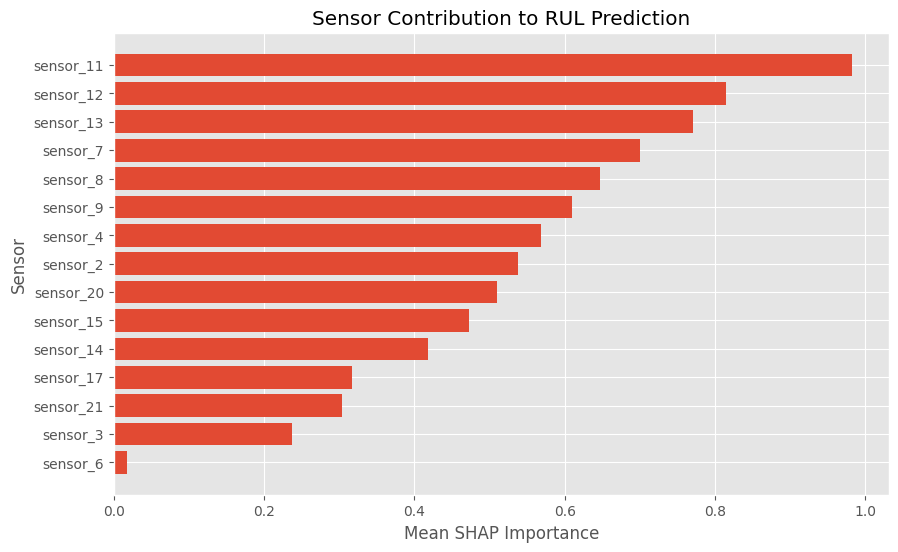

In [164]:
#Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(

    importance_df['Feature'],

    importance_df['Importance']
)

plt.xlabel("Mean SHAP Importance")

plt.ylabel("Sensor")

plt.title(
    "Sensor Contribution to RUL Prediction"
)

plt.gca().invert_yaxis()

plt.show()

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\245888921.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


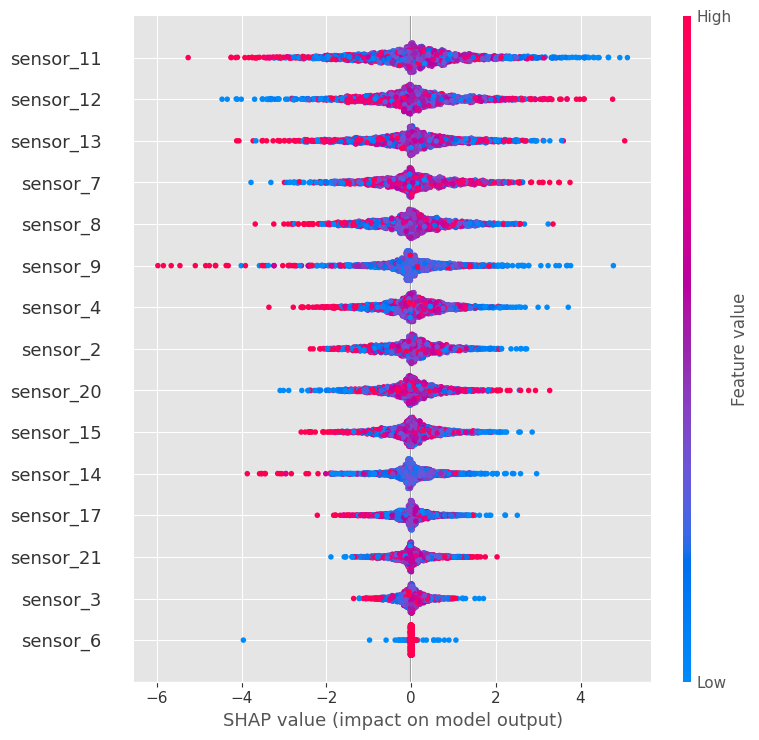

<Figure size 640x480 with 0 Axes>

In [303]:
shap.summary_plot(
    shap_values.reshape(-1, len(selected_features)),
    X_val[:50].reshape(-1, len(selected_features)),
    feature_names=selected_features
)
plt.savefig(
    "../reports/shap_importance.png"
)

In [165]:
importance_df.to_csv(
    "../data/processed/shap_feature_importance.csv",
    index=False
)

In [175]:
def fallback_insight(row):

    fp = row['Failure_Probability']
    rul = row['Predicted_RUL']
    cost = row['Total_Financial_Impact']

    if fp > 0.8:

        return (
            f"""
            Critical degradation risk detected.

            Estimated RUL:
            {rul:.1f} cycles.

            Projected maintenance exposure:
            ₹{cost:,.0f}.

            Immediate intervention recommended
            to avoid unplanned operational losses.
            """
        )

    elif fp > 0.5:

        return (
            f"""
            Moderate degradation trend observed.

            Estimated RUL:
            {rul:.1f} cycles.

            Preventive maintenance scheduling
            is recommended within the next quarter.
            """
        )

    else:

        return (
            f"""
            Asset health remains within acceptable limits.

            Estimated RUL:
            {rul:.1f} cycles.

            Continue monitoring operational conditions.
            """
        )


print("Done!")

Done!


In [176]:
import os

from openai import OpenAI

from dotenv import load_dotenv


load_dotenv()


client = OpenAI(

    api_key=os.getenv("GROQ_API_KEY"),

    base_url="https://api.groq.com/openai/v1"
)

print("Done!")

Done!


In [198]:
def llm_insight(row):

    prompt = f"""

    You are an industrial financial risk analyst.

    Analyze the following asset:

    Predicted Remaining Useful Life:
    {row['Predicted_RUL']:.1f}

    Failure Probability:
    {row['Failure_Probability']:.2f}

    Total Financial Exposure:
    ₹{row['Total_Financial_Impact']:,.0f}

    Maintenance Action:
    {row['Maintenance_Action']}

    Generate a concise executive-level
    maintenance risk insight for a CFO.

    Keep response under 80 words.
    """

    response = client.chat.completions.create(

        model="llama-3.1-8b-instant",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],

        temperature=0.3
    )

    return response.choices[0].message.content

In [178]:
def generate_ai_insight(row, mode='LLM-Powered'):

    try:

        if mode == 'LLM-Powered':

            return llm_insight(row)

        else:

            return fallback_insight(row)

    except Exception:

        return fallback_insight(row)

print("Done!")

Done!


In [186]:
results_df['Rule_Based_Insight'] = results_df.apply(
    fallback_insight,
    axis=1
)

print("Rule-Based Insights Generated!")


Rule-Based Insights Generated!


In [187]:
results_df['LLM_Insight'] = results_df[
    'Rule_Based_Insight'
]

print("LLM Insight Column Initialized!")

LLM Insight Column Initialized!


In [209]:
# =========================================
# SELECT TOP 10 HIGH-RISK ASSETS
# =========================================

critical_assets = results_df.nlargest(

    10,

    'Total_Financial_Impact'
).copy()

print("Top 10 Critical Assets Selected!")

print(
    critical_assets[
        [
            'Predicted_RUL',
            'Failure_Probability',
            'Total_Financial_Impact'
        ]
    ]
)

Top 10 Critical Assets Selected!
    Predicted_RUL  Failure_Probability  Total_Financial_Impact
12       2.742610             0.978059                 1940000
14       3.074803             0.975402                 1940000
19       3.377243             0.972982                 1940000
24       1.237899             0.990097                 1940000
36       1.603956             0.987168                 1940000
45      12.741594             0.898067                 1940000
52       2.295176             0.981639                 1940000
55       2.066739             0.983466                 1940000
60      12.323237             0.901414                 1940000
73      18.711014             0.850312                 1940000


In [217]:
critical_assets['LLM_Insight'] = critical_assets.progress_apply(

    lambda row: generate_ai_insight(
        row,
        mode='LLM-Powered'
    ),

    axis=1
)

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.31it/s]


In [218]:
results_df.loc[
    critical_assets.index,
    'LLM_Insight'
] = critical_assets['LLM_Insight']

In [219]:
results_df.to_csv(
    "../data/processed/final_dashboard_data.csv",
    index=False
)

In [214]:
results_df.to_csv(
    "../data/processed/final_dashboard_data.csv",
    index=False
)

print("Final Dashboard Data Saved!")

Final Dashboard Data Saved!


In [215]:
print(results_df.columns)

Index(['Actual_RUL', 'Predicted_RUL', 'Maintenance_Action',
       'Failure_Probability', 'Maintenance_Cost', 'Downtime_Hours',
       'Production_Loss', 'Total_Financial_Impact', 'AI_Insight',
       'Rule_Based_Insight', 'LLM_Insight'],
      dtype='object')


In [223]:
results_df[
    [
        'Rule_Based_Insight',
        'LLM_Insight'
    ]
].sample(10)

,Rule_Based_Insight,LLM_Insight
1145,\n Moderate degradation trend obser...,\n Moderate degradation trend obser...
1936,\n Asset health remains within acce...,\n Asset health remains within acce...
2974,\n Asset health remains within acce...,\n Asset health remains within acce...
2200,\n Critical degradation risk detect...,\n Critical degradation risk detect...
3403,\n Critical degradation risk detect...,\n Critical degradation risk detect...
1992,\n Asset health remains within acce...,\n Asset health remains within acce...
2228,\n Asset health remains within acce...,\n Asset health remains within acce...
2327,\n Moderate degradation trend obser...,\n Moderate degradation trend obser...
1799,\n Asset health remains within acce...,\n Asset health remains within acce...
943,\n Critical degradation risk detect...,\n Critical degradation risk detect...


In [199]:
test_row = critical_assets.iloc[0]

print(
    llm_insight(test_row)
)

**Maintenance Risk Insight**

Asset: High-Risk Equipment

* Predicted Remaining Useful Life: 2.7 years (short lifespan)
* Failure Probability: 98% (extremely high risk)
* Total Financial Exposure: ₹1,940,000 (significant potential loss)

**Recommendation:** Immediate Maintenance is recommended to mitigate the high risk of failure. A thorough inspection and repair should be conducted to prevent potential losses and minimize downtime.


In [224]:
results_df.loc[
    critical_assets.index,
    [
        'Rule_Based_Insight',
        'LLM_Insight'
    ]
]

,Rule_Based_Insight,LLM_Insight
12,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset: High-Ri...
14,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset: High-Ri...
19,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset ID: [Ins...
24,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset ID: [Ins...
36,\n Critical degradation risk detect...,"**Maintenance Risk Insight**\n\nAsset: ₹1,940,..."
45,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset: High-Ri...
52,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset at High ...
55,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset: High-Ri...
60,\n Critical degradation risk detect...,**Maintenance Risk Insight:**\n\nAsset ID: [In...
73,\n Critical degradation risk detect...,**Maintenance Risk Insight**\n\nAsset ID: [Ins...


In [349]:
# Replace ₹ with Rs. everywhere

results_df['LLM_Insight'] = results_df[
    'LLM_Insight'
].str.replace(
    '₹',
    'Rs.',
    regex=False
)

results_df['Rule_Based_Insight'] = results_df[
    'Rule_Based_Insight'
].str.replace(
    '₹',
    'Rs.',
    regex=False
)

print("Currency Symbols Replaced!")

Currency Symbols Replaced!


In [350]:
print(
    results_df['LLM_Insight']
    .str.contains('₹')
    .sum()
)

print(
    results_df['Rule_Based_Insight']
    .str.contains('₹')
    .sum()
)

0
0


In [324]:
from fpdf import FPDF

import pandas as pd

In [325]:
pdf = FPDF()

pdf.set_auto_page_break(
    auto=True,
    margin=15
)

pdf.add_page()

In [326]:
pdf.set_font(
    "Arial",
    style='B',
    size=20
)

pdf.cell(

    200,

    10,

    txt="Predictive Maintenance Executive Report",

    ln=True,

    align='C'
)

pdf.ln(10)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\238384890.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\238384890.py:7: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\238384890.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(


In [327]:
total_assets = len(results_df)

high_risk_assets = len(

    results_df[
        results_df['Failure_Probability'] > 0.7
    ]
)

total_exposure = results_df[
    'Total_Financial_Impact'
].sum()

In [328]:
pdf.set_font(
    "Arial",
    style='B',
    size=16
)

pdf.cell(
    200,
    10,
    txt="Executive Summary",
    ln=True
)

pdf.set_font(
    "Arial",
    size=12
)

summary_text = f"""

Total Assets Monitored:
{total_assets}

High-Risk Assets:
{high_risk_assets}

Projected Financial Exposure:
Rs.{total_exposure:,.0f}

The predictive maintenance platform
identified elevated maintenance risk
among critical industrial assets,
with projected capex exposure
requiring proactive intervention.
"""

pdf.multi_cell(
    0,
    8,
    summary_text
)

pdf.ln(5)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\3489655973.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\3489655973.py:7: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\3489655973.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\3489655973.py:14: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


In [329]:
pdf.set_font(
    "Arial",
    style='B',
    size=16
)

pdf.cell(
    200,
    10,
    txt="Top Critical Assets",
    ln=True
)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\1117390741.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\1117390741.py:7: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\1117390741.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(


False

In [330]:
top_assets = results_df.nlargest(

    5,

    'Total_Financial_Impact'
)

In [331]:
pdf.set_font(
    "Arial",
    size=11
)

for idx, row in top_assets.iterrows():

    asset_text = f"""

Asset ID: {idx}

Predicted RUL:
{row['Predicted_RUL']:.1f}

Failure Probability:
{row['Failure_Probability']:.2f}

Financial Exposure:
Rs.{row['Total_Financial_Impact']:,.0f}

Recommended Action:
{row['Maintenance_Action']}
"""

    pdf.multi_cell(
        0,
        7,
        asset_text
    )

    pdf.ln(2)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\2654893578.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


In [332]:
pdf.set_font(
    "Arial",
    style='B',
    size=16
)

pdf.cell(
    200,
    10,
    txt="AI Executive Insights",
    ln=True
)

pdf.set_font(
    "Arial",
    size=11
)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\352168143.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\352168143.py:7: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\352168143.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\352168143.py:14: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


In [333]:
for idx, row in top_assets.iterrows():

    insight_text = f"""

Asset ID: {idx}

{row['LLM_Insight']}
"""

    pdf.multi_cell(
        0,
        7,
        insight_text
    )

    pdf.ln(3)

In [334]:
pdf.set_font(
    "Arial",
    style='B',
    size=16
)

pdf.cell(
    200,
    10,
    txt="Top Failure Drivers",
    ln=True
)

pdf.set_font(
    "Arial",
    size=11
)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\784931805.py:1: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\784931805.py:7: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\784931805.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(
C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\784931805.py:14: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


In [335]:
top_shap = importance_df.head(5)

for _, row in top_shap.iterrows():

    driver_text = f"""

Feature:
{row['Feature']}

Importance Score:
{row['Importance']:.4f}
"""

    pdf.multi_cell(
        0,
        7,
        driver_text
    )

    pdf.ln(2)

In [336]:
from datetime import datetime


pdf.ln(10)

pdf.set_font(
    "Arial",
    style='I',
    size=10
)

pdf.multi_cell(

    0,

    6,

    f"""
Report Generated By:
VALIARIA Predictive Maintenance Intelligence Platform

Generated On:
{datetime.now().strftime('%d-%m-%Y %H:%M:%S')}
"""
)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\2712789160.py:6: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


True

In [337]:
pdf.image(

    "../reports/shap_importance.png",

    x=20,

    w=170
)

pdf.ln(10)

In [338]:
top_assets = results_df.nlargest(
    10,
    'Total_Financial_Impact'
)

plt.figure(figsize=(8,5))

plt.bar(

    top_assets.index.astype(str),

    top_assets['Total_Financial_Impact']
)

plt.xlabel("Asset ID")

plt.ylabel("Financial Exposure")

plt.title("Top Critical Assets")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/top_assets.png"
)

plt.close()

In [339]:
pdf.image(
    "../reports/top_assets.png",
    x=20,
    w=170
)

{'data': b'x\x9c\xed\xbd\ttT\xe7y\xc7\xed4\x8b\xe3$m\xd26i\xd2l_\x92\xf6\xa4M\x93&m\xd2$\xa7I\xd3$]\xd2\x9c\x9e$=m\x8e\xb6AH\x83V$@\x80\x90e\x06c\xc0\x18#\xcb\xecH\x80\xc4&\x16\xcbB\xc6F`L\xc0l\x02\x83\xc0 \x03f\x91\r\xc8,B\x08\x84AH\x08$,\t1\xdf\xf3\xe9\x9a\xfb\x8dG\xa0;\x9aW\xba\xcf\xbc\xcf\xfb\xff\x1d\x0eg\xe6\xce\x9d;\xff\x9f\x9eY\xfe3su\xf5\x90\x1f\x00\x00\x00\x00\x00\x0c(\x0fq\x07\x00\x00\x00\x00\x00\x90\x06\n\x16\x00\x00\x00\x00\xc0\x00\x83\x82\x05\x00\x00\x00\x000\xc0\xa0`\x01\x00\x00\x00\x00\x0c0(X\x00\x00\x00\x00\x00\x03\x0c\n\x16\x00\x00\x00\x00\xc0\x00\x83\x82\x05\x00\x00\x00\x000\xc0\xa0`\x01\x00\x00\x00\x00\x0c0(X\x00\x00\x00\x00\x00\x03\x0c\n\x16\x00\x00\x00\x00\xc0\x00\x83\x82\x05\x00\x00\x00\x000\xc0\xa0`\x01\x00\x00\x00\x00\x0c0(X\x00\x00\x00\x00\x00\x03\x0c\n\x16\x00\x00\x00\x00\xc0\x00\x83\x82\x05\x00\xd0\x95\x92\x92\x92\x87\x1ez\x88\xfew\\\x93V\xfb\xf9\xcf\x7f>\xb0\xb7~\xee\xdc9\xdalbb\xe2\xc0n\x16\x00 \x03\x14,\x00\xcc\xe5\xa1\x10\x08\xa5\xbe\xa8p\xeb\xd6\xad9s\xe

In [340]:
plt.figure(figsize=(8,5))

plt.hist(
    simulation_totals,
    bins=30
)

plt.xlabel("Forecasted Cost")

plt.ylabel("Frequency")

plt.title("Monte Carlo Maintenance Cost Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/monte_carlo.png"
)

plt.close()

In [341]:
pdf.image(
    "../reports/monte_carlo.png",
    x=20,
    w=170
)

{'data': b'x\x9c\xed\xbd\tt\x14\xd7\x99\xbfMv;{\xe2d\x92\xc9$\xf9\x9c\xc96\x89\x93\x93=9\x93\x99d\x92xf\x9cm\xb2K\x02!\x84\x90\xd8$\x16\x13Y\xc8\x801NX\x8d\t\x18\x0cx\x01\x0c\xc1\x18c\x8ce\x8c1\xc6\x18c\x82\x01\xe3\x15\xb0\x01cV\xb1\x18\xcb\x98\x00f\x11X\x80\xd0\xf7\x8e\xeeP\xffr\xb7\xa4VuW\xf5{\xeb\xf6\xf3\x9c\xdf\xd1\xe9\xae\xaa\xae\xae\xee\xb7\xee\xbdOWW\x97:4\x01\x00\x00\x00@\xa8t\xd0\xde\x00\x00\x00\x00\x00\xd7@\xb0\x00\x00\x00\x00B\x06\xc1\x02\x00\x00\x00\x08\x19\x04\x0b\x00\x00\x00 d\x10,\x00\x00\x00\x80\x90A\xb0\x00\x00\x00\x00B\x06\xc1\x02\x00\x00\x00\x08\x19\x04\x0b\x00\x00\x00 d\x10,\x00\x00\x00\x80\x90A\xb0\x00\x00\x00\x00B\x06\xc1\x02\x00\x00\x00\x08\x19\x04\x0b\x00\x00\x00 d\x10,\x00\x00\x00\x80\x90A\xb0\x00\x00\x00\x00B\x06\xc1\x02p\x81Y\xb3fu\xe8\xd0A\xfejoH\xab\\w\xddu\xb2\x85+W\xae\xd4\xde\x10P\xa3\xb6\xb6V\xf6\x81\xae]\xbbF\xf7\x14\xb2\xfe\xff\xf8\x8f\xff\xf0\xeefa\xaf\xcb\xc2\x8b\x82\x98\x82`\x81uth\xe6-oy\xcb\xce\x9d;\x93\xe7\xfe\xe8G?2\x0bD$\x13\xd2;\xcb\xcaC_\xed

In [342]:
from datetime import datetime


pdf.ln(10)

pdf.set_font(
    "Arial",
    style='I',
    size=10
)

pdf.multi_cell(

    0,

    6,

    f"""
Report Generated By:
VALIARIA Predictive Maintenance Intelligence Platform

Generated On:
{datetime.now().strftime('%d-%m-%Y %H:%M:%S')}
"""
)

C:\Users\Kartik\AppData\Local\Temp\ipykernel_26896\2712789160.py:6: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font(


False

In [343]:
pdf.output(
    "../reports/executive_report.pdf"
)

print("Executive Report Generated!")

Executive Report Generated!


In [348]:
# =========================================================
# report_generator.py
# =========================================================

from fpdf import FPDF
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


def generate_executive_report(

    results_df,

    importance_df,

    monte_carlo_costs
):

    # =====================================================
    # CREATE REPORTS FOLDER
    # =====================================================

    os.makedirs(
        "../reports",
        exist_ok=True
    )


    # =====================================================
    # CREATE ASSET IDS
    # =====================================================

    results_df['Asset_ID'] = [

        f"AST-{1000+i}"

        for i in range(len(results_df))
    ]


    # =====================================================
    # CREATE RISK LEVELS
    # =====================================================

    def risk_level(prob):

        if prob > 0.85:

            return "CRITICAL"

        elif prob > 0.60:

            return "HIGH"

        elif prob > 0.40:

            return "MODERATE"

        else:

            return "LOW"


    results_df['Risk_Level'] = results_df[
        'Failure_Probability'
    ].apply(risk_level)


    # =====================================================
    # TOP ASSETS GRAPH
    # =====================================================

    top_assets_chart = results_df.nlargest(

        10,

        'Total_Financial_Impact'
    )

    plt.figure(figsize=(8,5))

    plt.bar(

        top_assets_chart['Asset_ID'],

        top_assets_chart['Total_Financial_Impact']
    )

    plt.xlabel("Asset ID")

    plt.ylabel("Financial Exposure")

    plt.title("Top Critical Assets")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        "../reports/top_assets.png"
    )

    plt.close()


    # =====================================================
    # SHAP GRAPH
    # =====================================================

    top_shap = importance_df.head(10)

    plt.figure(figsize=(8,5))

    plt.barh(

        top_shap['Feature'],

        top_shap['Importance']
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.title("Top Failure Drivers")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.savefig(
        "../reports/shap_importance.png"
    )

    plt.close()


    # =====================================================
    # MONTE CARLO GRAPH
    # =====================================================

    plt.figure(figsize=(8,5))

    plt.hist(

        simulation_totals,

        bins=30
    )

    plt.xlabel("Forecasted Maintenance Cost")

    plt.ylabel("Frequency")

    plt.title(
        "Monte Carlo Maintenance Cost Distribution"
    )

    plt.tight_layout()

    plt.savefig(
        "../reports/monte_carlo.png"
    )

    plt.close()


    # =====================================================
    # CREATE PDF
    # =====================================================

    pdf = FPDF()

    pdf.set_auto_page_break(
        auto=True,
        margin=15
    )

    pdf.add_page()


    # =====================================================
    # TITLE
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=20
    )

    pdf.cell(

        200,

        10,

        txt="Predictive Maintenance Executive Report",

        ln=True,

        align='C'
    )

    pdf.ln(10)


    # =====================================================
    # EXECUTIVE SUMMARY
    # =====================================================

    total_assets = len(results_df)

    high_risk_assets = len(

        results_df[
            results_df['Failure_Probability'] > 0.7
        ]
    )

    total_exposure = results_df[
        'Total_Financial_Impact'
    ].sum()

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="Executive Summary",

        ln=True
    )

    pdf.set_font(
        "Arial",
        size=12
    )

    summary_text = f"""

Total Assets Monitored:
{total_assets}

High-Risk Assets:
{high_risk_assets}

Projected Financial Exposure:
Rs. {total_exposure:,.0f}

The predictive maintenance platform
identified elevated maintenance risk
among critical industrial assets,
with projected capex exposure
requiring proactive intervention.
"""

    pdf.multi_cell(
        0,
        8,
        summary_text
    )

    pdf.ln(5)


    # =====================================================
    # TOP CRITICAL ASSETS
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="Top Critical Assets",

        ln=True
    )

    pdf.image(

        "../reports/top_assets.png",

        x=20,

        w=160
    )

    pdf.ln(10)


    top_assets = results_df.nlargest(

        5,

        'Total_Financial_Impact'
    )

    pdf.set_font(
        "Arial",
        size=11
    )

    for _, row in top_assets.iterrows():

        asset_text = f"""

Asset ID:
{row['Asset_ID']}

Risk Level:
{row['Risk_Level']}

Predicted RUL:
{row['Predicted_RUL']:.1f}

Failure Probability:
{row['Failure_Probability']:.2f}

Financial Exposure:
Rs. {row['Total_Financial_Impact']:,.0f}

Recommended Action:
{row['Maintenance_Action']}
"""

        pdf.multi_cell(
            0,
            7,
            asset_text
        )

        pdf.ln(2)


    # =====================================================
    # AI INSIGHTS
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="AI Executive Insights",

        ln=True
    )

    pdf.set_font(
        "Arial",
        size=11
    )

    for _, row in top_assets.iterrows():

        insight_text = f"""

Asset ID:
{row['Asset_ID']}

{row['LLM_Insight']}
"""

        pdf.multi_cell(
            0,
            7,
            insight_text
        )

        pdf.ln(3)


    # =====================================================
    # SHAP FAILURE DRIVERS
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="Top Failure Drivers",

        ln=True
    )

    pdf.image(

        "../reports/shap_importance.png",

        x=20,

        w=160
    )

    pdf.ln(10)


    # =====================================================
    # MONTE CARLO FORECAST
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="Monte Carlo Risk Forecast",

        ln=True
    )

    pdf.image(

        "../reports/monte_carlo.png",

        x=20,

        w=160
    )

    pdf.ln(10)

    pdf.set_font(
        "Arial",
        size=11
    )

    mean_cost = simulation_totals.mean()

    max_cost = simulation_totals.max()

    min_cost = simulation_totals.min()

    mc_text = f"""

Average Forecasted Maintenance Cost:
Rs. {mean_cost:,.0f}

Worst-Case Maintenance Exposure:
Rs. {max_cost:,.0f}

Best-Case Maintenance Exposure:
Rs. {min_cost:,.0f}

Monte Carlo simulations indicate
significant variability in future
maintenance expenditure.
"""

    pdf.multi_cell(
        0,
        8,
        mc_text
    )


    # =====================================================
    # CONCLUSION
    # =====================================================

    pdf.set_font(
        "Arial",
        style='B',
        size=16
    )

    pdf.cell(

        200,

        10,

        txt="Conclusion",

        ln=True
    )

    pdf.set_font(
        "Arial",
        size=11
    )

    conclusion_text = """

The AI-powered predictive maintenance
platform combines machine learning,
financial forecasting, explainable AI,
and executive intelligence to identify
operational risk and forecast
maintenance-related financial exposure.

The system enables proactive
maintenance planning and improved
capital allocation for industrial
organizations.
"""

    pdf.multi_cell(
        0,
        8,
        conclusion_text
    )


    # =====================================================
    # FOOTER
    # =====================================================

    pdf.ln(10)

    pdf.set_font(
        "Arial",
        style='I',
        size=10
    )

    footer_text = f"""

Report Generated By:
Industrial Decision Intelligence System built by KARTIK

Generated On:
{datetime.now().strftime('%d-%m-%Y %H:%M:%S')}
"""

    pdf.multi_cell(
        0,
        6,
        footer_text
    )


    # =====================================================
    # EXPORT PDF
    # =====================================================

    report_path = "../reports/executive_report.pdf"

    pdf.output(report_path)

    return report_path